# 04-Vector Databases & Metadata

In Lesson 03, we successfully converted our text chunks into dense continuous vectors using a Bi-Encoder. We now have 10,000 vectors floating in $\mathbb{R}^{384}$ space.

If we store these vectors in a standard Python list and calculate the dot product against a user query, it is fast enough for 10,000 documents. But Enterprise RAG systems (like answering questions across a global law firm's entire history) contain **100 Million to 1 Billion vectors**.

Calculating 1 Billion dot products per query will destroy your API latency. Furthermore, semantic similarity is not always enough. A user might ask: *"Show me the HR policies regarding remote work, but **only documents published after 2023**."*

To achieve sub-millisecond search at scale, and to enforce strict deterministic rules (Dates, Authors, Departments), we must deploy a specialized architecture: **The Vector Database** (e.g., Qdrant, Pinecone, FAISS, Milvus).

Let's set up our environment to master the physics of Vector Storage and Metadata Filtering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import time

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Vector Database Environment Ready.")

✅ Systems Architecture & Vector Database Environment Ready.


# 1. The Anatomy of a Vector Record

Standard relational databases (PostgreSQL, MySQL) store data in rows and columns, optimized for B-Tree indexing. Vector Databases store data as complex geometric objects.

Every record in a true Vector Database contains exactly three components:

1. **The Vector ($v$)**: The high-dimensional float array ($\mathbb{R}^d$) generated by the Embedding Model. This is used for semantic search.
2. **The Payload / Metadata ($m$)**: A standard JSON dictionary containing hard facts (e.g., `{"department": "HR", "year": 2024}`). This is used for strict filtering.
3. **The ID**: A unique UUID mapping the vector back to the original text chunk stored in blob storage.

# 2. The Metadata Filtering Problem

Combining dense vector search with hard metadata filtering introduces one of the most notoriously difficult mathematical problems in RAG engineering.

Let $\mathcal{D}$ be our database of vectors, $q$ be our query vector, and $f(m) \in \{0,1\}$ be a Boolean metadata filter. We want to find the top $K$ vectors that maximize Cosine Similarity, strictly subject to $f(m) = 1$.

There are two naive ways to engineer this, and **both are mathematically flawed**.

### Strategy A: Post-Filtering

1. Perform a standard K-Nearest Neighbor (KNN) search to find the top $K=10$ most semantically similar vectors.
2. After retrieval, iterate through the 10 vectors and discard any that do not match the metadata filter (`year == 2024`).

* **The Fatal Flaw (Recall Collapse)**: If the vector space is densely packed with documents from 2022, the initial KNN search might return ten 2022 documents. The Post-Filter will discard all of them, returning **zero results** to the user, even if a perfect 2024 document was sitting at position $K=11$.

### Strategy B: Pre-Filtering

1. Scan the entire database and create a temporary subset of vectors where `year == 2024`.
2. Perform the KNN search only on that subset.

* **The Fatal Flaw (Index Destruction)**: To search millions of vectors in milliseconds, databases use Approximate Nearest Neighbor (ANN) graphs (like HNSW). If you Pre-Filter, you mathematically shatter the graph connections. The search algorithm will hit dead ends and crash.

*(Note: Modern enterprise Vector DBs solve this using Custom Single-Stage Filtering, where the graph topology is dynamically evaluated alongside the payload during the traversal).*

# 3. Architecting an In-Memory Vector Database

To prove the physics of the Post-Filtering Recall Collapse, we will code a raw Python Vector Database from scratch. We will populate it, execute an exact KNN search, and demonstrate the catastrophic failure of naive post-filtering.

In [2]:
# --- 🗄️ Enterprise Vector DB Simulation ---

class RawVectorDatabase:
    def __init__(self, dimension: int):
        self.dimension = dimension
        self.vectors = []     # List of numpy arrays
        self.metadata = []    # List of JSON dicts
        self.ids = []         # List of strings
        
    def insert(self, record_id: str, vector: np.ndarray, meta: Dict):
        # Enforce L2 Normalization for Cosine Similarity
        norm_vector = vector / np.linalg.norm(vector)
        self.vectors.append(norm_vector)
        self.metadata.append(meta)
        self.ids.append(record_id)
        
    def _compute_similarities(self, query_vector: np.ndarray) -> np.ndarray:
        """Matrix Multiplication (Dot Product) across the entire DB"""
        query_norm = query_vector / np.linalg.norm(query_vector)
        db_matrix = np.vstack(self.vectors) # Shape: [N, D]
        # Since both are L2 normalized, Dot Product == Cosine Similarity
        return np.dot(db_matrix, query_norm)
        
    def search_naive_post_filter(self, query: np.ndarray, top_k: int, required_dept: str):
        """ANTI-PATTERN: Search first, filter later."""
        similarities = self._compute_similarities(query)
        
        # 1. Get Top-K indices regardless of metadata
        top_k_indices = np.argsort(similarities)[::-1][:top_k]
        
        # 2. Apply Post-Filter
        results = []
        for idx in top_k_indices:
            if self.metadata[idx].get("department") == required_dept:
                results.append((self.ids[idx], similarities[idx], self.metadata[idx]))
                
        return results

    def search_exact_pre_filter(self, query: np.ndarray, top_k: int, required_dept: str):
        """EXACT SEARCH: Filter first, search remaining. (Only works for small datasets)"""
        similarities = self._compute_similarities(query)
        
        results = []
        # We evaluate the entire database
        for idx in range(len(self.vectors)):
            if self.metadata[idx].get("department") == required_dept:
                results.append((idx, similarities[idx]))
                
        # Sort the filtered list
        results.sort(key=lambda x: x[1], reverse=True)
        
        # Return top K
        final_results = []
        for idx, sim in results[:top_k]:
            final_results.append((self.ids[idx], sim, self.metadata[idx]))
            
        return final_results

# 1. Initialize the DB
DIMENSION = 2
db = RawVectorDatabase(dimension=DIMENSION)

# 2. Populate the DB with a cluster of Engineering docs, and one distant HR doc
print("--- 📥 Populating Vector Database ---")
np.random.seed(42)

# Generate 50 Engineering documents closely clustered
for i in range(50):
    vec = np.array([0.8, 0.2]) + np.random.normal(0, 0.05, 2)
    db.insert(f"eng_{i}", vec, {"department": "Engineering"})

# Generate exactly 1 HR document slightly further away, but still relevant to the query
hr_vec = np.array([0.6, 0.4])
db.insert("hr_1", hr_vec, {"department": "HR"})

print(f"Database contains {len(db.vectors)} vectors.")

# 3. The User Query
# The user asks a question that leans slightly towards the engineering cluster, 
# but explicitly requests HR data.
query_vector = np.array([0.7, 0.3])
TOP_K = 5
FILTER = "HR"

print(f"\n--- 🔍 Executing Query: Top {TOP_K} where Department == '{FILTER}' ---")

# Execute Post-Filtering
post_results = db.search_naive_post_filter(query_vector, TOP_K, FILTER)
print(f"\nNaive Post-Filtering Results returned: {len(post_results)}")
if len(post_results) == 0:
    print("❌ FATAL: Recall Collapse! The Top-5 vectors were all Engineering. The filter discarded them all. The user gets a blank screen.")

# Execute Pre-Filtering (Exact Search)
pre_results = db.search_exact_pre_filter(query_vector, TOP_K, FILTER)
print(f"\nExact Pre-Filtering Results returned: {len(pre_results)}")
if len(pre_results) > 0:
    print(f"✅ SUCCESS: Retrieved {pre_results[0][0]} with similarity {pre_results[0][1]:.4f}")

--- 📥 Populating Vector Database ---
Database contains 51 vectors.

--- 🔍 Executing Query: Top 5 where Department == 'HR' ---

Naive Post-Filtering Results returned: 0
❌ FATAL: Recall Collapse! The Top-5 vectors were all Engineering. The filter discarded them all. The user gets a blank screen.

Exact Pre-Filtering Results returned: 1
✅ SUCCESS: Retrieved hr_1 with similarity 0.9833


# 4. Visualizing the Filtering Topology

To mathematically prove why the Post-Filtering architecture collapses, let's visualize the 2D vector space. We will plot the dense Engineering cluster, the isolated HR document, and the exact geometric radius of the Top-K search.

/tmp/ipykernel_3916/2295422918.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


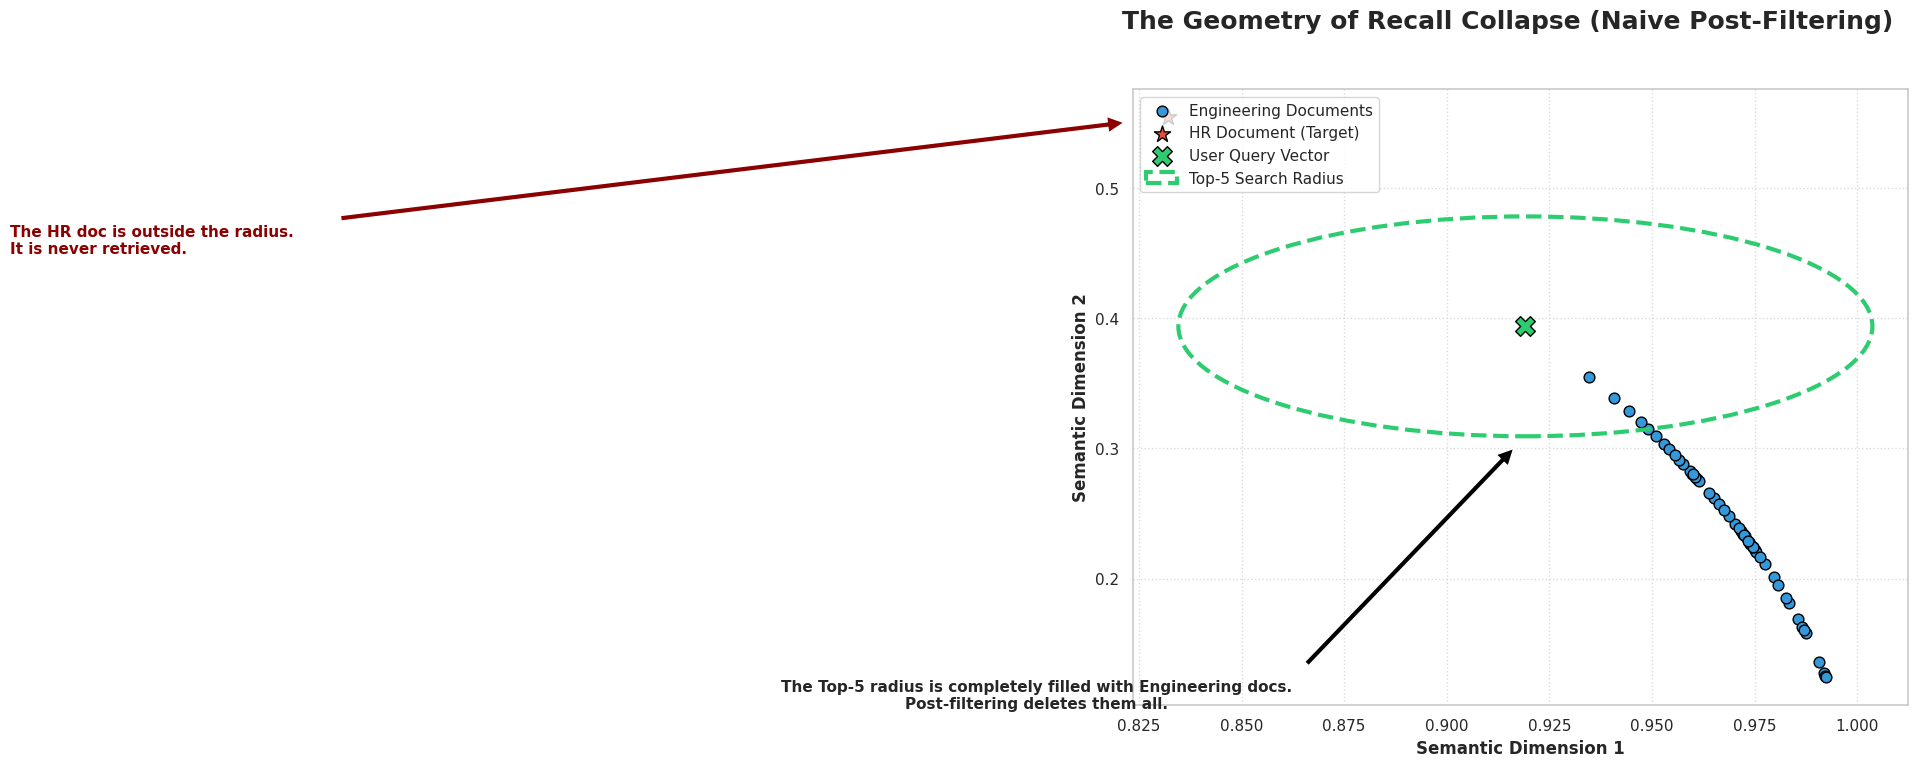


--- 💡 Engineering Insight ---
Look closely at the Green Circle. When the Database executes `search(query, top_k=5)`, it draws that circle and grabs the 5 points inside it. Because the Engineering cluster is so dense, the circle fills up immediately.
When the Post-Filter runs (`WHERE dept == HR`), it looks at those 5 points, realizes none of them are HR, and deletes them. The Red Star (the actual answer) was sitting just outside the radius. It was never even evaluated. The user's query fails entirely.


In [3]:
# Visualizing the Recall Collapse Physics
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("The Geometry of Recall Collapse (Naive Post-Filtering)", fontsize=18, fontweight='bold')

# Extract vectors for plotting
vectors = np.vstack(db.vectors)
eng_mask = [m.get("department") == "Engineering" for m in db.metadata]
hr_mask = [m.get("department") == "HR" for m in db.metadata]

eng_vectors = vectors[eng_mask]
hr_vectors = vectors[hr_mask]

# Normalize query for plotting
q_norm = query_vector / np.linalg.norm(query_vector)

# Plot Engineering Vectors
ax.scatter(eng_vectors[:, 0], eng_vectors[:, 1], c='#3498db', s=60, edgecolors='black', label="Engineering Documents")

# Plot HR Vector
ax.scatter(hr_vectors[:, 0], hr_vectors[:, 1], c='#e74c3c', s=150, marker='*', edgecolors='black', label="HR Document (Target)")

# Plot Query Vector
ax.scatter(q_norm[0], q_norm[1], c='#2ecc71', s=200, marker='X', edgecolors='black', label="User Query Vector")

# Calculate the radius of the Top-K search
# Find the distance to the 5th closest vector
sims = np.dot(vectors, q_norm)
top_k_indices = np.argsort(sims)[::-1][:TOP_K]
kth_vector = vectors[top_k_indices[-1]]
# Radius is euclidean distance to kth vector
radius = np.linalg.norm(q_norm - kth_vector)

# Draw the Top-K Boundary
circle = plt.Circle((q_norm[0], q_norm[1]), radius, color='#2ecc71', fill=False, linestyle='--', linewidth=3, label=f"Top-{TOP_K} Search Radius")
ax.add_patch(circle)

# Add annotations
ax.annotate('The Top-5 radius is completely filled with Engineering docs.\nPost-filtering deletes them all.', 
            xy=(q_norm[0], q_norm[1] - radius), xytext=(0.8, 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=11, fontweight='bold', ha='center')

ax.annotate('The HR doc is outside the radius.\nIt is never retrieved.', 
            xy=(hr_vectors[0, 0], hr_vectors[0, 1]), xytext=(0.55, 0.45),
            arrowprops=dict(facecolor='darkred', shrink=0.05), fontsize=11, fontweight='bold', color='darkred')

ax.set_xlabel("Semantic Dimension 1", fontsize=12, fontweight='bold')
ax.set_ylabel("Semantic Dimension 2", fontsize=12, fontweight='bold')
ax.legend(loc="upper left")
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the Green Circle. When the Database executes `search(query, top_k=5)`, it draws that circle and grabs the 5 points inside it. Because the Engineering cluster is so dense, the circle fills up immediately.")
print("When the Post-Filter runs (`WHERE dept == HR`), it looks at those 5 points, realizes none of them are HR, and deletes them. The Red Star (the actual answer) was sitting just outside the radius. It was never even evaluated. The user's query fails entirely.")

## Real-World Use Case or Analogy:

Think of the Vector DB Filtering dilemma like **Hiring a Specialized Employee**:

* **The Query**: You need an elite software engineer who speaks fluent Japanese.
* **Post-Filtering (The Collapse)**: You go to a massive tech conference (The Vector DB) and find the Top 10 absolute best programmers in the building based purely on coding skills (KNN Search). You bring them into a room and ask, *"Who here speaks Japanese?"* None of them do. You send them all home. You failed to hire anyone, even though there was a great Japanese-speaking programmer sitting in the 12th row.
* **Pre-Filtering (The Index Destruction)**: You stand on a chair and yell, *"Everyone who doesn't speak Japanese, leave the building immediately!"* 99% of the people leave. Now you have a room of 5 people. You can easily find the best programmer among them. *However*, kicking 99% of the people out caused chaos, broke all the social groups, and took hours to organize.